In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn category_encoders -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, Normalizer,
    OneHotEncoder, OrdinalEncoder, TargetEncoder, LabelEncoder,
    PolynomialFeatures, KBinsDiscretizer, FunctionTransformer, PowerTransformer
)
import category_encoders as ce

print("Библиотеки загружены!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 940.1 kB/s eta 0:00:00
Библиотеки загружены!


In [ ]:
#   Готовим реалистичный датасет: объявления о продаже квартир
#   С пропусками, категориями, выбросами
np.random.seed(42)
N = 500

# Числовые признаки — сразу создаём как float, чтобы позже можно было вставить NaN
area = np.random.normal(60, 25, N).clip(20, 200)            # площадь (м²), float64
rooms = np.random.randint(1, 6, N).astype(float)            # количество комнат, теперь float
floor = np.random.randint(1, 25, N).astype(float)           # этаж, float
total_floors = np.random.randint(1, 25, N).astype(float)    # всего этажей, float
age = np.random.randint(0, 50, N).astype(float)             # возраст здания, float

# Категорийные признаки
district = np.random.choice(['Центр', 'Спальный', 'Пригород', 'Промзона'], N)
condition = np.random.choice(['требует ремонта', 'среднее', 'хорошее', 'отличное'], N)

# Целевая переменная: цена в млн руб.
price = (2.5 + area*0.12 + rooms*0.8 - age*0.03 + floor*0.1
         + (district=='Центр')*3 + (condition=='отличное')*2
         + np.random.normal(0, 1.5, N))

# Вносим пропуски (~10% в каждом числовом признаке) — теперь это работает, потому что тип float
for col in ['area', 'rooms', 'floor', 'total_floors', 'age']:
    mask = np.random.random(N) < 0.1
    locals()[col][mask] = np.nan

# Собираем DataFrame
df = pd.DataFrame({
    'area': area, 'rooms': rooms, 'floor': floor,
    'total_floors': total_floors, 'age': age,
    'district': district, 'condition': condition, 'price': price
})

# Вносим пропуски в категорийные признаки
for col in ['district', 'condition']:
    mask = np.random.random(N) < 0.05
    df.loc[mask, col] = np.nan

X = df.drop('price', axis=1)
y = (df['price'] > df['price'].median()).astype(int)  # задача классификации: дороже/дешевле медианы

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Тренировочных примеров: {len(X_train)}")
print(f"Пропуски в данных:\n{X_train.isna().sum()}")

Тренировочных примеров: 400
Пропуски в данных:
area            40
rooms           46
floor           37
total_floors    43
age             38
district        17
condition       17
dtype: int64


## МАСШТАБИРОВАНИЕ — выравниваем громкость

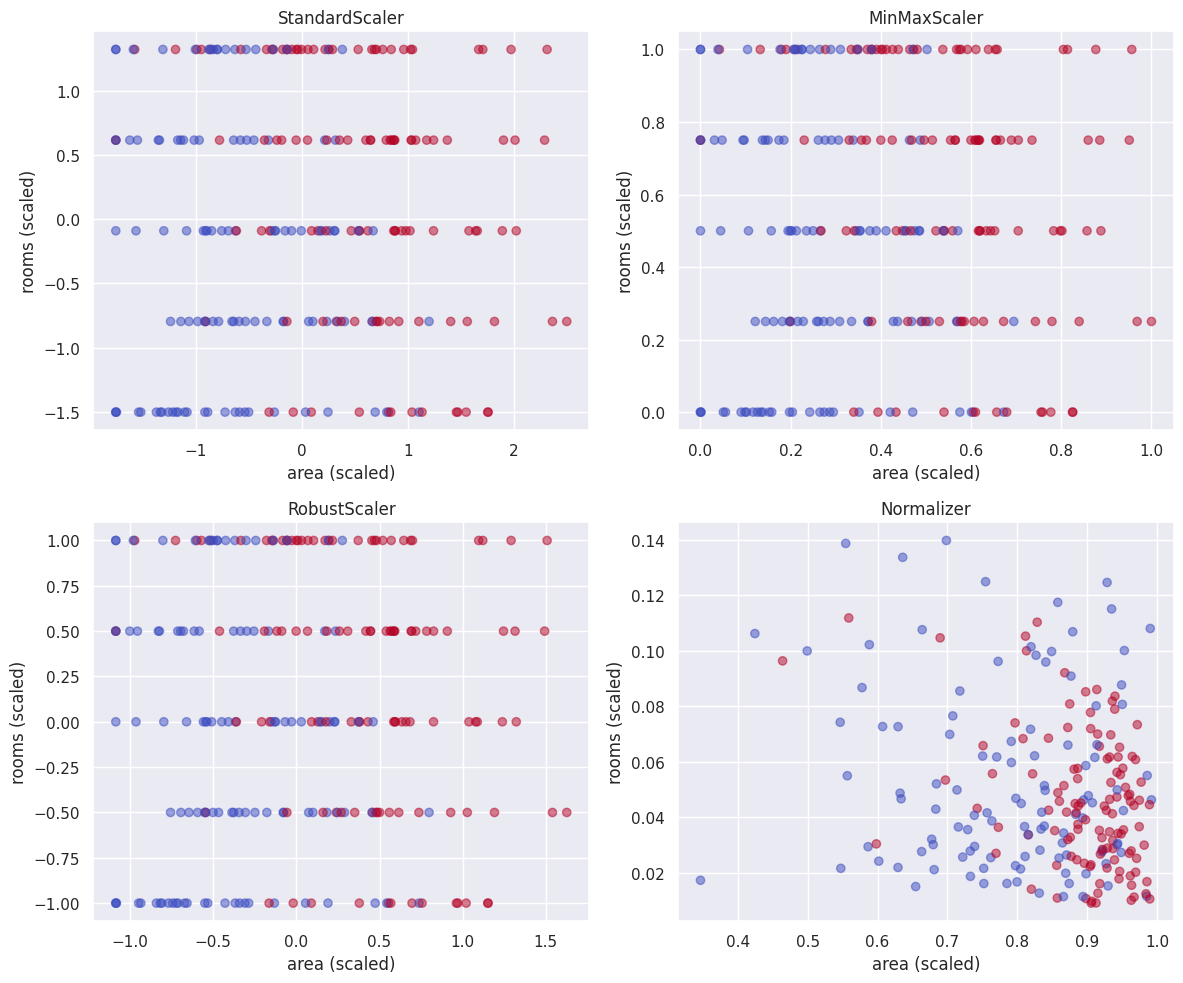

In [ ]:
# Выделим только числовые колонки для демонстрации
num_cols = ['area', 'rooms', 'floor', 'total_floors', 'age']
X_num = X_train[num_cols].dropna().copy()

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'Normalizer': Normalizer()
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, scaler) in zip(axes.flatten(), scalers.items()):
    X_scaled = scaler.fit_transform(X_num)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.5, c=y_train[X_num.index], cmap='coolwarm')
    ax.set_title(name)
    ax.set_xlabel('area (scaled)')
    ax.set_ylabel('rooms (scaled)')
plt.tight_layout()
plt.show()

**Что видим:**
- StandardScaler центрирует и нормализует.
- MinMaxScaler сжимает в [0, 1].
- RobustScaler менее чувствителен к выбросам.
- Normalizer проецирует на единичную окружность.

## КОДИРОВАНИЕ КАТЕГОРИЙ — текст в числа

In [ ]:
# КОДИРОВАНИЕ КАТЕГОРИЙ — превращаем текст в числа
# Сначала заполним пропуски в категорийных колонках самым частым значением
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy='most_frequent')  # заменяет NaN на самую частую категорию
# Убедимся, что колонки, которые будем кодировать, не содержат NaN
X_train_cat = X_train[['condition', 'district']].copy()
X_train_cat[:] = cat_imputer.fit_transform(X_train_cat)  # fit_transform возвращает массив, присваиваем обратно
# Обновляем оригинальные колонки
X_train[['condition', 'district']] = X_train_cat
X_test[['condition', 'district']] = cat_imputer.transform(X_test[['condition', 'district']])

# LabelEncoder — только для y (целевой переменной)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print("LabelEncoder (классы):", le.classes_)

# OrdinalEncoder — для признаков с естественным порядком
ord_enc = OrdinalEncoder(categories=[['требует ремонта', 'среднее', 'хорошее', 'отличное']])
cond_encoded = ord_enc.fit_transform(X_train[['condition']])  # теперь без NaN
print("OrdinalEncoder (condition), первые 5:", cond_encoded[:5].flatten())

# OneHotEncoder — для номинальных категорий
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
district_ohe = ohe.fit_transform(X_train[['district']])
print("OneHotEncoder (district), первые 5 строк:\n", district_ohe[:5])
print("Имена колонок:", ohe.get_feature_names_out(['district']))

# TargetEncoder (sklearn)
te = TargetEncoder(target_type='binary', smooth='auto', random_state=42)
district_te = te.fit_transform(X_train[['district']], y_train_enc)
print("TargetEncoder (district), первые 5:", district_te[:5].flatten())

# Покажем средние значения target'а по районам
unique_districts = X_train[['district']].copy()
unique_districts['encoded'] = te.fit_transform(X_train[['district']], y_train_enc)
print("\nСредние значения target'а по районам (закодированные):")
print(unique_districts.groupby('district')['encoded'].mean())

# TargetEncoder из category_encoders
ce_te = ce.TargetEncoder(cols=['district'], smoothing=10)
district_cete = ce_te.fit_transform(X_train[['district']], y_train_enc)
print("\nCategory Encoders TargetEncoder (первые 5):\n", district_cete[:5])

LabelEncoder (классы): [0 1]
OrdinalEncoder (condition), первые 5: [1. 1. 2. 3. 3.]
OneHotEncoder (district), первые 5 строк:
 [[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]
Имена колонок: ['district_Пригород' 'district_Промзона' 'district_Спальный'
 'district_Центр']
TargetEncoder (district), первые 5: [0.42391226 0.34423458 0.42391226 0.5146141  0.53020969]

Средние значения target'а по районам (закодированные):
district
Пригород    0.383658
Промзона    0.504823
Спальный    0.374612
Центр       0.678874
Name: encoded, dtype: float64

Category Encoders TargetEncoder (первые 5):
      district
249  0.384702
433  0.384702
19   0.384702
322  0.504000
332  0.504000


## ЗАПОЛНЕНИЕ ПРОПУСКОВ

In [ ]:
# SimpleImputer
imp_median = SimpleImputer(strategy='median')
X_imp_median = imp_median.fit_transform(X_train[num_cols])
print("SimpleImputer median, форма:", X_imp_median.shape)

# KNNImputer (медленнее, но умнее)
knn_imp = KNNImputer(n_neighbors=5)
X_knn = knn_imp.fit_transform(X_train[num_cols].iloc[:200])  # для скорости возьмём 200 строк
print("KNNImputer, форма:", X_knn.shape)

SimpleImputer median, форма: (400, 5)
KNNImputer, форма: (200, 5)


## ДОПОЛНИТЕЛЬНЫЕ ПРЕОБРАЗОВАНИЯ

In [ ]:
# PolynomialFeatures — создаём взаимодействия
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_imp_median[:100])
print("Полиномиальные признаки, форма:", X_poly.shape)

# KBinsDiscretizer — разбиваем area на категории
disc = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
X_area_binned = disc.fit_transform(X_imp_median[:, 0:1])  # первая колонка — area
print("Дискретизация area (0=низкая, 1=средняя, 2=высокая):\n", X_area_binned[:10].flatten())

# FunctionTransformer — логарифмирование
log_transformer = FunctionTransformer(np.log1p, validate=True)
X_log = log_transformer.fit_transform(X_imp_median[:, 0:1])
print("log1p(area):\n", X_log[:5].flatten())

# PowerTransformer (Yeo-Johnson)
pt = PowerTransformer(method='yeo-johnson')
X_pt = pt.fit_transform(X_imp_median)
print("PowerTransformer, форма:", X_pt.shape)

Полиномиальные признаки, форма: (100, 20)
Дискретизация area (0=низкая, 1=средняя, 2=высокая):
 [1. 1. 0. 0. 1. 0. 0. 1. 0. 0.]
log1p(area):
 [4.26443246 4.36866978 3.24619552 3.70239972 4.14146848]
PowerTransformer, форма: (400, 5)


## СОБИРАЕМ ФИНАЛЬНЫЙ ПАЙПЛАЙН

In [ ]:
# Разделяем признаки по типам
numeric_features = ['area', 'rooms', 'floor', 'total_floors', 'age']
categorical_features = ['district', 'condition']

# Трансформеры
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=500))
])

pipeline.fit(X_train, y_train_enc)
y_pred_enc = pipeline.predict(X_test)
accuracy = accuracy_score(y_test_enc, y_pred_enc)
print(f"Accuracy финального пайплайна: {accuracy:.3f}")

Accuracy финального пайплайна: 0.900


## 🎸 ТВОРЧЕСКОЕ ЗАДАНИЕ

1. Замени StandardScaler на MinMaxScaler в пайплайне — изменилась ли accuracy?
2. Попробуй вместо OneHotEncoder использовать TargetEncoder (не забудь, что он требует y при fit).
3. Добавь PolynomialFeatures в числовой трансформер — как изменился счёт?
4. Сравни accuracy пайплайна с KNNImputer и SimpleImputer.
5. Сгенерируй отчёт classification_report для финальной модели.